| Pieza (Semana 6) | Fórmula | Cambio en este lab |
|---|---|---|
| `make_positional_encoding` | $PE(t,2i)=\sin(t/10000^{2i/d})$, $PE(t,2i+1)=\cos(t/10000^{2i/d})$ | igual, con `max_len = block_size = 128` |
| `layer_norm` | $\gamma \odot \frac{x-\mu}{\sqrt{\sigma^2+\epsilon}}+\beta$ | igual |
| `masked_self_attention` | $\text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}} + M\right)V$, con $M_{ij}=-\infty$ si $j>i$ | ahora procesa **batches** `(B, T, d_model)` |
| FFN | $\text{ReLU}(xW_1+b_1)W_2+b_2$ | misma fórmula, con $d_{ff}=4\,d_{model}=512$ (en S6 era $2\,d_{model}$) |
| Bloque decoder | Add & LayerNorm | se apilan **`n_layers = 3`** bloques (orden Pre-LN, ver Task 1.2) |
| LM head | $\text{logits}=xW_{lm}+b_{lm}$ | vocabulario de **65 caracteres** en lugar de palabras |
| `generate` | $\text{softmax}(z/\tau)$ + `multinomial` | se separa en 3 estrategias: greedy, top-k y top-p |

## Bloque 0: imports y semillas

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, os, random, time, urllib.request
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

SEED = 1337
torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__} | device: {device}')

PyTorch 2.14.0+cpu | device: cpu


# Task 1

## Task 1.1: dataset, vocabulario y batches

In [ ]:
# Descarga del corpus tiny_shakespeare (~1.1M caracteres)
URL = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
DATA_PATH = 'tiny_shakespeare.txt'
if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(URL, DATA_PATH)

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    text = f.read()

print(f'Caracteres totales: {len(text):,}')
print(text[:250])

Caracteres totales: 1,115,394
----------------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.



In [3]:
# Vocabulario de caracteres unicos (ordenado para que los indices sean reproducibles)
chars = sorted(set(text))
vocab_size = len(chars)
assert vocab_size == 65, f'El vocabulario debe tener 65 caracteres, tiene {vocab_size}'

# Mappings bidireccionales caracter <-> indice
stoi = {ch: i for i, ch in enumerate(chars)}   # char  -> int
itos = {i: ch for ch, i in stoi.items()}       # int   -> char

encode = lambda s: [stoi[c] for c in s]          # str       -> list[int]
decode = lambda l: ''.join(itos[int(i)] for i in l)  # list[int] -> str

print(f'vocab_size = {vocab_size}')
print('Vocabulario:', repr(''.join(chars)))
print('encode("ROMEO:") =', encode('ROMEO:'))
print('decode(encode("ROMEO:")) =', decode(encode('ROMEO:')))

vocab_size = 65
Vocabulario: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
encode("ROMEO:") = [30, 27, 25, 17, 27, 10]
decode(encode("ROMEO:")) = ROMEO:


In [4]:
# Codificar todo el texto como secuencia de indices
data = torch.tensor(encode(text), dtype=torch.long)

# Split 90/10 respetando el orden temporal (sin shuffle): el bloque final del texto
# queda para validacion, asi el modelo nunca ve durante el entrenamiento el texto que se evalua.
n_train = int(0.9 * len(data))
train_data = data[:n_train]
val_data   = data[n_train:]
print(f'data: {data.shape} | train: {len(train_data):,} tokens | val: {len(val_data):,} tokens')

data: torch.Size([1115394]) | train: 1,003,854 tokens | val: 111,540 tokens


In [5]:
# Hiperparametros minimos del enunciado
block_size = 128   # T: largo de contexto
d_model    = 128
n_heads    = 4
n_layers   = 3
batch_size = 64
lr         = 3e-4
epochs     = 20    # el enunciado pide minimo 10. Con 20 se obtiene val ppl ~6.0 (con 10 da ~7.2)

d_k  = d_model // n_heads   # 32 por cabeza
d_ff = 4 * d_model          # 512, como en Vaswani et al.

def get_batch(split, batch_size=batch_size, block_size=block_size):
    '''
    Genera un batch de secuencias de largo fijo.
      x[b] = data[i : i+T]        (entrada)
      y[b] = data[i+1 : i+T+1]    (objetivo = entrada desplazada un paso al futuro)
    Asi en cada posicion t el modelo aprende P(x_{t+1} | x_1..x_t).
    '''
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size - 1, (batch_size,))
    x = torch.stack([d[i:i + block_size] for i in ix])
    y = torch.stack([d[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch('train')
print(f'x: {tuple(xb.shape)}  y: {tuple(yb.shape)}')
print('x[0][:30] =', repr(decode(xb[0][:30])))
print('y[0][:30] =', repr(decode(yb[0][:30])))
assert torch.equal(xb[:, 1:], yb[:, :-1]), 'y debe ser x desplazado un paso'

x: (64, 128)  y: (64, 128)
x[0][:30] = ' if die, be brief,\nThat our sw'
y[0][:30] = 'if die, be brief,\nThat our swi'


## Task 1.2

Se reutilizan `make_positional_encoding`, `layer_norm` y la atención con máscara causal de la Semana 6. Cambian tres cosas:

1. **Batches:** los tensores pasan de `(T, d)` a `(B, T, d)`.
2. **Profundidad:** se apilan `n_layers = 3` bloques decoder.
3. **Orden de la normalización (Pre-LN):** en la Semana 6 el bloque era *Post-LN*, $x \leftarrow \text{LN}(x + \text{Sublayer}(x))$. Con 3 bloques se usa *Pre-LN* (GPT-2): $x \leftarrow x + \text{Sublayer}(\text{LN}(x))$, más una LN final antes de la cabeza LM. Así el camino residual queda limpio y el gradiente fluye mejor. En una prueba con la configuración mínima (10 épocas), Post-LN se quedó en perplejidad ≈ 8.1 y Pre-LN llegó a ≈ 7.2.

In [ ]:
# Piezas reutilizadas de la Semana 6
def make_positional_encoding(max_len, d_model):
    '''PE(t,2i) = sin(t / 10000^(2i/d_model)),  PE(t,2i+1) = cos(t / 10000^(2i/d_model))'''
    pe = torch.zeros(max_len, d_model)
    pos = torch.arange(max_len).unsqueeze(1).float()
    div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)
    return pe

def layer_norm(x, gamma, beta, eps=1e-5):
    '''LN(x) = gamma * (x - mu) / sqrt(var + eps) + beta, sobre la ultima dimension'''
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, unbiased=False, keepdim=True)
    return gamma * (x - mean) / torch.sqrt(var + eps) + beta

# Mascara causal: True (triangulo superior) = posicion futura, se enmascara con -inf
CAUSAL_MASK = torch.triu(torch.ones(block_size, block_size), diagonal=1).bool().to(device)
PE = make_positional_encoding(block_size, d_model).to(device)
print(CAUSAL_MASK[:5, :5].int())

tensor([[0, 1, 1, 1, 1],
        [0, 0, 1, 1, 1],
        [0, 0, 0, 1, 1],
        [0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0]], dtype=torch.int32)


In [7]:
class DecoderBlock(nn.Module):
    '''Un bloque decoder: masked multi-head self-attention + FFN, ambos con residual (Pre-LN).'''
    def __init__(self, d_model, d_ff, n_heads):
        super().__init__()
        self.n_heads, self.d_k, self.d_model = n_heads, d_model // n_heads, d_model
        std = 0.02  # init pequena estilo GPT-2 (en S6 era 0.1 con d_model=32)
        # Proyecciones de atencion WQ, WK, WV, WO (d_model x d_model)
        self.WQ = nn.Parameter(torch.randn(d_model, d_model) * std)
        self.WK = nn.Parameter(torch.randn(d_model, d_model) * std)
        self.WV = nn.Parameter(torch.randn(d_model, d_model) * std)
        self.WO = nn.Parameter(torch.randn(d_model, d_model) * std)
        # LayerNorm 1 y 2
        self.gamma1 = nn.Parameter(torch.ones(d_model));  self.beta1 = nn.Parameter(torch.zeros(d_model))
        self.gamma2 = nn.Parameter(torch.ones(d_model));  self.beta2 = nn.Parameter(torch.zeros(d_model))
        # FFN
        self.W1 = nn.Parameter(torch.randn(d_model, d_ff) * std); self.bias1 = nn.Parameter(torch.zeros(d_ff))
        self.W2 = nn.Parameter(torch.randn(d_ff, d_model) * std); self.bias2 = nn.Parameter(torch.zeros(d_model))

    def masked_self_attention(self, x):
        '''
        x: (B, T, d_model) -> out: (B, T, d_model), attn_w: (B, n_heads, T, T)
        Attention(Q,K,V) = softmax(Q K^T / sqrt(d_k) + M) V,   M_ij = -inf si j > i
        '''
        B, T, _ = x.shape
        # 1. Q = xWQ, K = xWK, V = xWV  -> reshape a (B, n_heads, T, d_k)
        Q = (x @ self.WQ).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        K = (x @ self.WK).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = (x @ self.WV).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        # 2. scores escalados por sqrt(d_k) para que el softmax no se sature
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)        # (B, h, T, T)
        # 3. mascara causal: cada token solo atiende a posiciones <= t
        scores = scores.masked_fill(CAUSAL_MASK[:T, :T], float('-inf'))
        attn_w = F.softmax(scores, dim=-1)
        # 4. concatenar cabezas y proyectar con WO
        out = (attn_w @ V).transpose(1, 2).contiguous().view(B, T, self.d_model)
        return out @ self.WO, attn_w

    def feed_forward(self, x):
        '''FFN(x) = ReLU(x W1 + b1) W2 + b2  (por posicion)'''
        return F.relu(x @ self.W1 + self.bias1) @ self.W2 + self.bias2

    def forward(self, x):
        # Pre-LN: x = x + Sublayer(LN(x))
        att_out, _ = self.masked_self_attention(layer_norm(x, self.gamma1, self.beta1))
        x = x + att_out
        x = x + self.feed_forward(layer_norm(x, self.gamma2, self.beta2))
        return x


class MiniGPT(nn.Module):
    '''Transformer decoder-only a nivel de caracter (Mini-GPT de la Semana 6 con n_layers bloques).'''
    def __init__(self, V, d_model, d_ff, n_heads, n_layers):
        super().__init__()
        self.E = nn.Parameter(torch.randn(V, d_model) * 0.02)          # embeddings de caracteres
        self.blocks = nn.ModuleList([DecoderBlock(d_model, d_ff, n_heads) for _ in range(n_layers)])
        self.gammaf = nn.Parameter(torch.ones(d_model)); self.betaf = nn.Parameter(torch.zeros(d_model))
        self.Wlm = nn.Parameter(torch.randn(d_model, V) * 0.02)        # LM head
        self.blm = nn.Parameter(torch.zeros(V))

    def forward(self, idx, targets=None):
        '''
        idx: (B, T) indices -> logits: (B, T, V)
        Si hay targets: loss = CE promedio = -(1/N) sum_t log P(x_{t+1} | x_<=t)
        '''
        B, T = idx.shape
        x = self.E[idx] + PE[:T]                       # embedding + positional encoding
        for blk in self.blocks:
            x = blk(x)
        x = layer_norm(x, self.gammaf, self.betaf)     # LN final (Pre-LN)
        logits = x @ self.Wlm + self.blm               # proyeccion al vocabulario
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

torch.manual_seed(SEED)
model = MiniGPT(vocab_size, d_model, d_ff, n_heads, n_layers).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Parametros: {n_params:,}')

# Chequeo: loss inicial ~ ln(65) = 4.17 (distribucion casi uniforme)
_, l0 = model(xb, yb)
print(f'Loss inicial: {l0.item():.4f}  (esperado ~ ln(65) = {math.log(vocab_size):.4f})')

Parametros: 610,241
Loss inicial: 4.2301  (esperado ~ ln(65) = 4.1744)


In [8]:
@torch.no_grad()
def evaluate_full(model, d, block_size=block_size, bs=64):
    '''
    Recorre TODO el split en ventanas no traslapadas de block_size y devuelve
    la CE media por token: (1/N) sum_t L_t, donde N = numero total de tokens evaluados.
    Se usa reduction='sum' para acumular L_t exactamente y dividir por N al final.
    '''
    model.eval()
    n_win = (len(d) - 1) // block_size
    X = d[:n_win * block_size].view(n_win, block_size)
    Y = d[1:n_win * block_size + 1].view(n_win, block_size)
    total, N = 0.0, 0
    for i in range(0, n_win, bs):
        x, y = X[i:i + bs].to(device), Y[i:i + bs].to(device)
        logits, _ = model(x)
        total += F.cross_entropy(logits.view(-1, vocab_size), y.view(-1), reduction='sum').item()
        N += y.numel()
    model.train()
    return total / N, N

# Una epoca = numero de batches necesarios para cubrir (en esperanza) todos los tokens de train una vez
steps_per_epoch = len(train_data) // (batch_size * block_size)
print(f'steps_per_epoch = {len(train_data):,} // ({batch_size}*{block_size}) = {steps_per_epoch}')

steps_per_epoch = 1,003,854 // (64*128) = 122


In [9]:
CKPT = 'minigpt_shakespeare.pt'
RETRAIN = False   # True para forzar reentrenamiento aunque exista el checkpoint

if os.path.exists(CKPT) and not RETRAIN:
    ck = torch.load(CKPT, map_location=device)
    model.load_state_dict(ck['model']); history = ck['history']
    print(f'Checkpoint cargado ({CKPT}). Historial del entrenamiento original:')
    for e, (tl, vl) in enumerate(zip(history['train'], history['val']), 1):
        print(f'Epoca {e:2d}/{len(history["train"])} | train {tl:.4f} | val {vl:.4f} | val ppl {math.exp(vl):.2f}')
else:
    torch.manual_seed(SEED)
    model = MiniGPT(vocab_size, d_model, d_ff, n_heads, n_layers).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train': [], 'val': []}
    t0 = time.time()
    for epoch in range(epochs):
        model.train(); running = 0.0
        for step in range(steps_per_epoch):
            xb, yb = get_batch('train')
            _, loss = model(xb, yb)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            running += loss.item()
        train_loss = running / steps_per_epoch            # promedio de la epoca
        val_loss, _ = evaluate_full(model, val_data)      # CE sobre todo el set de validacion
        history['train'].append(train_loss); history['val'].append(val_loss)
        print(f'Epoca {epoch+1:2d}/{epochs} | train {train_loss:.4f} | val {val_loss:.4f} '
              f'| val ppl {math.exp(val_loss):.2f} | {time.time()-t0:.0f}s')
    torch.save({'model': model.state_dict(), 'history': history}, CKPT)

Checkpoint cargado (minigpt_shakespeare.pt). Historial del entrenamiento original:


Epoca  1/20 | train 3.3915 | val 3.3480 | val ppl 28.44
Epoca  2/20 | train 3.1299 | val 2.7232 | val ppl 15.23
Epoca  3/20 | train 2.5978 | val 2.5219 | val ppl 12.45
Epoca  4/20 | train 2.4256 | val 2.3590 | val ppl 10.58
Epoca  5/20 | train 2.3007 | val 2.2632 | val ppl 9.61
Epoca  6/20 | train 2.2222 | val 2.1907 | val ppl 8.94
Epoca  7/20 | train 2.1411 | val 2.1272 | val ppl 8.39
Epoca  8/20 | train 2.0646 | val 2.0799 | val ppl 8.00
Epoca  9/20 | train 1.9949 | val 2.0108 | val ppl 7.47
Epoca 10/20 | train 1.9323 | val 1.9702 | val ppl 7.17
Epoca 11/20 | train 1.8747 | val 1.9424 | val ppl 6.98
Epoca 12/20 | train 1.8314 | val 1.9137 | val ppl 6.78
Epoca 13/20 | train 1.7922 | val 1.8904 | val ppl 6.62
Epoca 14/20 | train 1.7549 | val 1.8785 | val ppl 6.54
Epoca 15/20 | train 1.7223 | val 1.8551 | val ppl 6.39
Epoca 16/20 | train 1.7005 | val 1.8429 | val ppl 6.32
Epoca 17/20 | train 1.6778 | val 1.8227 | val ppl 6.19
Epoca 18/20 | train 1.6531 | val 1.8088 | val ppl 6.10
Epoca

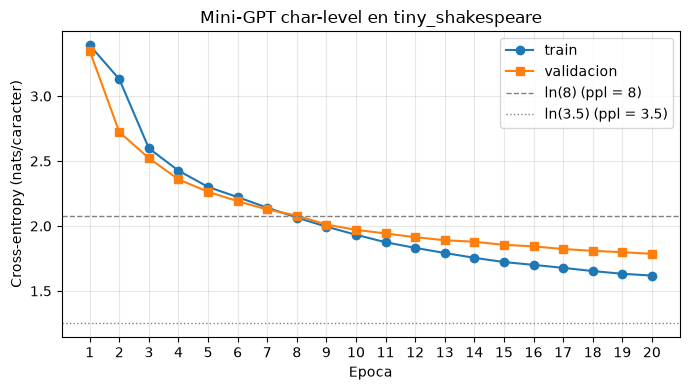

In [10]:
ep = range(1, len(history['train']) + 1)
plt.figure(figsize=(7, 4))
plt.plot(ep, history['train'], 'o-', label='train')
plt.plot(ep, history['val'], 's-', label='validacion')
plt.axhline(math.log(8.0), ls='--', c='gray', lw=1, label='ln(8) (ppl = 8)')
plt.axhline(math.log(3.5), ls=':',  c='gray', lw=1, label='ln(3.5) (ppl = 3.5)')
plt.xlabel('Epoca'); plt.ylabel('Cross-entropy (nats/caracter)')
plt.title('Mini-GPT char-level en tiny_shakespeare')
plt.xticks(list(ep)); plt.grid(alpha=.3); plt.legend(); plt.tight_layout()
plt.savefig('lab8_loss_curve.png', dpi=110); plt.show()

In [11]:
val_ce, N_val = evaluate_full(model, val_data)
val_ppl = math.exp(val_ce)
print(f'N tokens evaluados : {N_val:,}')
print(f'CE media validacion: {val_ce:.4f} nats/caracter')
print(f'Perplejidad val    : {val_ppl:.3f}')
print('Dentro del rango [3.5, 8.0]:', 3.5 <= val_ppl <= 8.0)

N tokens evaluados : 111,488
CE media validacion: 1.7859 nats/caracter
Perplejidad val    : 5.965
Dentro del rango [3.5, 8.0]: True


## Task 1.3

Las tres funciones reciben los **logits crudos** $z\in\mathbb{R}^{V}$ de la última posición y devuelven el índice del siguiente token. El softmax con temperatura y el muestreo de una distribución categórica también se implementan a mano:

- **Softmax con temperatura:** $P(w_i\mid\text{ctx})=\dfrac{\exp(z_i/\tau)}{\sum_j\exp(z_j/\tau)}$. Antes de exponenciar se resta $\max_j z_j/\tau$ para evitar overflow; el resultado no cambia.
- **Muestreo categórico (CDF inversa):** se toma $u\sim U(0,1)$ y se devuelve el primer $i$ tal que $\sum_{j\le i}P_j \ge u$.

In [12]:
def softmax_temperature(logits, tau=1.0):
    '''P(w_i | ctx) = exp(z_i / tau) / sum_j exp(z_j / tau)   (los -inf dan probabilidad 0)'''
    z = logits / tau
    z = z - z.max()              # estabilidad numerica: softmax es invariante a restar una constante
    e = torch.exp(z)
    return e / e.sum()

def sample_categorical(probs, generator=None):
    '''Muestreo por CDF inversa: primer i con F(i) = sum_{j<=i} p_j > u,  u ~ U(0,1)
    (desigualdad estricta: un token con p_i = 0 no hace crecer F, asi que nunca se elige)'''
    cdf = torch.cumsum(probs, dim=0)
    u = torch.rand(1, generator=generator, device=probs.device) * cdf[-1]   # *cdf[-1] por redondeo
    return int(torch.searchsorted(cdf, u, right=True).clamp(max=len(probs) - 1).item())


def greedy_sample(logits):
    '''Greedy: w* = argmax_i z_i (determinista; el argmax es igual para logits y para softmax)'''
    return int(torch.argmax(logits).item())

def top_k_sample(logits, k, tau=1.0, generator=None):
    '''
    Top-k con temperatura:
      1. z' = z / tau
      2. conservar los k mayores; z'_i = -inf para el resto
      3. P = softmax(z')  -> solo los k candidatos tienen masa
      4. muestrear de P
    '''
    z = logits / tau
    k = min(k, z.numel())
    top_idx = torch.sort(z, descending=True).indices[:k]       # indices de los k mayores
    z_masked = torch.full_like(z, float('-inf'))
    z_masked[top_idx] = z[top_idx]                              # el resto queda en -inf
    probs = softmax_temperature(z_masked, tau=1.0)              # ya se dividio por tau
    return sample_categorical(probs, generator)

def top_p_sample(logits, p, tau=1.0, generator=None, return_info=False):
    '''
    Top-p (nucleus) con temperatura:
      1. P = softmax(z / tau)
      2. ordenar P de mayor a menor
      3. incluir tokens hasta que la probabilidad acumulada supere p
         (se incluye el token que cruza el umbral, asi el nucleo nunca queda vacio)
      4. renormalizar dentro del nucleo y muestrear
    '''
    probs = softmax_temperature(logits, tau)
    sorted_p, sorted_idx = torch.sort(probs, descending=True)
    cum = torch.cumsum(sorted_p, dim=0)
    keep = (cum - sorted_p) < p          # masa acumulada ANTES del token < p  => el token entra
    nucleus_p = sorted_p * keep
    nucleus_p = nucleus_p / nucleus_p.sum()                     # renormalizar
    j = sample_categorical(nucleus_p, generator)
    idx = int(sorted_idx[j].item())
    if return_info:
        return idx, {'nucleus_size': int(keep.sum().item()), 'p_max': float(sorted_p[0].item())}
    return idx

In [13]:
# Pruebas unitarias sobre logits de juguete
z = torch.tensor([2.0, 1.0, 0.5, 0.1, -1.0])
g = torch.Generator().manual_seed(0)

assert greedy_sample(z) == 0
# top-k con k=2 nunca debe producir indices fuera de {0,1}
assert set(top_k_sample(z, k=2, tau=1.0, generator=g) for _ in range(500)) <= {0, 1}
# top-k con k=1 equivale a greedy
assert all(top_k_sample(z, k=1, generator=g) == 0 for _ in range(50))

P = softmax_temperature(z, 1.0)
print('softmax(z)      =', P.numpy().round(3), '| coincide con F.softmax:', torch.allclose(P, F.softmax(z, -1)))
print('softmax(z/0.5)  =', softmax_temperature(z, 0.5).numpy().round(3), '(tau<1 concentra)')
print('softmax(z/2.0)  =', softmax_temperature(z, 2.0).numpy().round(3), '(tau>1 aplana)')
# top-p: con P = [.559,.205,.125,.084,.028] (acumulada .559,.764,.889,.973,1):
#   p=0.5 -> {0}; p=0.7 -> {0,1}; p=0.95 -> {0,1,2,3}  (se incluye el token que cruza p)
for pp in [0.5, 0.7, 0.95]:
    _, info = top_p_sample(z, pp, return_info=True)
    print(f'top-p p={pp}: tamano del nucleo = {info["nucleus_size"]}')

# Frecuencias empiricas vs teoricas (top-k k=3, tau=1)
cnt = Counter(top_k_sample(z, 3, 1.0, g) for _ in range(20000))
teo = F.softmax(z[:3], -1)
print('top-k=3 empirico:', [round(cnt[i] / 20000, 3) for i in range(3)], '| teorico:', teo.numpy().round(3))

softmax(z)      = [0.559 0.205 0.125 0.084 0.028] | coincide con F.softmax: True
softmax(z/0.5)  = [0.826 0.112 0.041 0.018 0.002] (tau<1 concentra)
softmax(z/2.0)  = [0.372 0.226 0.176 0.144 0.083] (tau>1 aplana)
top-p p=0.5: tamano del nucleo = 1
top-p p=0.7: tamano del nucleo = 2
top-p p=0.95: tamano del nucleo = 4


top-k=3 empirico: [0.627, 0.23, 0.142] | teorico: [0.629 0.231 0.14 ]


# Task 2

## Task 2.1

In [14]:
SAMPLERS = {'greedy': greedy_sample, 'top_k': top_k_sample, 'top_p': top_p_sample}

@torch.no_grad()
def generate(prompt, max_new_tokens, strategy, trace=False, **kwargs):
    '''
    prompt         : str, contexto inicial
    max_new_tokens : int, caracteres nuevos a generar
    strategy       : 'greedy' | 'top_k' | 'top_p'
    kwargs         : k, p, tau, generator (segun la estrategia)
    trace          : si True, tambien retorna por paso (char, P(char), p_max, tamano del nucleo top-p 0.95)
    Retorna el texto nuevo (sin el prompt) y opcionalmente la traza.
    '''
    model.eval()
    sampler = SAMPLERS[strategy]
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    steps = []
    for _ in range(max_new_tokens):
        ctx = idx[:, -block_size:]                 # recortar al contexto maximo
        logits, _ = model(ctx)
        z = logits[0, -1]                          # logits crudos del siguiente caracter
        nxt = sampler(z, **kwargs)
        if trace:
            pr = softmax_temperature(z, kwargs.get('tau', 1.0))
            _, info = top_p_sample(z, 0.95, kwargs.get('tau', 1.0), return_info=True)
            steps.append({'char': itos[nxt], 'p_chosen': float(pr[nxt]), 'p_max': float(pr.max()),
                          'nucleus95': info['nucleus_size'], 'prev': itos[int(idx[0, -1])]})
        idx = torch.cat([idx, torch.tensor([[nxt]], device=device)], dim=1)
    out = decode(idx[0, len(prompt):].tolist())
    return (out, steps) if trace else out

print(repr(generate('ROMEO:', 60, 'greedy')))

'\nWhat the shall the shall the shall the stand the stand\nThe '


In [15]:
PROMPT, N_SAMPLES, N_CHARS = 'ROMEO:', 5, 200
CONFIGS = {
    'A': ('greedy', {}),
    'B': ('top_k', {'k': 5,     'tau': 0.7}),
    'C': ('top_k', {'k': 50,    'tau': 1.0}),
    'D': ('top_p', {'p': 0.70,  'tau': 0.7}),
    'E': ('top_p', {'p': 0.95,  'tau': 1.0}),
}

samples, traces = {}, {}
for name, (strategy, params) in CONFIGS.items():
    samples[name], traces[name] = [], []
    for s in range(N_SAMPLES):
        g = torch.Generator(device=device).manual_seed(1000 * (ord(name) - 64) + s)  # reproducible
        kw = dict(params) if strategy == 'greedy' else dict(params, generator=g)
        out, tr = generate(PROMPT, N_CHARS, strategy, trace=True, **kw)
        samples[name].append(out); traces[name].append(tr)

for name, (strategy, params) in CONFIGS.items():
    print('=' * 80)
    print(f'Configuracion {name}: {strategy} {params}')
    print('=' * 80)
    for s, out in enumerate(samples[name]):
        print(f'--- Muestra {name}{s+1} ---')
        print(PROMPT + out)
    print()

Configuracion A: greedy {}
--- Muestra A1 ---
ROMEO:
What the shall the shall the shall the stand the stand
The stand the stand the stand the stand the stand
To the shall the stand the stand the stands
And the stand the stand the stand the stands
And t
--- Muestra A2 ---
ROMEO:
What the shall the shall the shall the stand the stand
The stand the stand the stand the stand the stand
To the shall the stand the stand the stands
And the stand the stand the stand the stands
And t
--- Muestra A3 ---
ROMEO:
What the shall the shall the shall the stand the stand
The stand the stand the stand the stand the stand
To the shall the stand the stand the stands
And the stand the stand the stand the stands
And t
--- Muestra A4 ---
ROMEO:
What the shall the shall the shall the stand the stand
The stand the stand the stand the stand the stand
To the shall the stand the stand the stands
And the stand the stand the stand the stands
And t
--- Muestra A5 ---
ROMEO:
What the shall the shall the shall the stan

### Métricas de diversidad por configuración

Para comparar con números y no solo leyendo las muestras, se calculan:
- **distinct-n:** fracción de n-gramas de caracteres únicos sobre el total (mayor = menos repetitivo).
- **% palabras reales:** fracción de las palabras generadas que existen en el vocabulario de tiny_shakespeare (aproxima la coherencia).
- **muestras únicas:** cuántas de las 5 muestras son distintas entre sí.
- **nucleo95 medio:** tamaño medio del núcleo top‑p con p=0.95, calculado con la τ de cada configuración (mide qué tan plana es la distribución que se está muestreando).
- **log P medio:** log-probabilidad media (bajo el modelo con $\tau=1$) de los caracteres elegidos. Mientras más alta, más "segura" la elección.

In [16]:
import re
corpus_words = set(re.findall(r"[a-zA-Z']+", text.lower()))

def distinct_n(s, n):
    grams = [s[i:i + n] for i in range(len(s) - n + 1)]
    return len(set(grams)) / max(1, len(grams))

@torch.no_grad()
def mean_logp(sample):
    ids = torch.tensor([encode(PROMPT + sample)], device=device)[:, -block_size - 1:]
    logits, _ = model(ids[:, :-1])
    lp = F.log_softmax(logits[0], -1)
    tgt = ids[0, 1:]
    lp = lp[torch.arange(len(tgt)), tgt][-N_CHARS:]
    return lp.mean().item()

rows = []
for name in CONFIGS:
    ss = samples[name]
    words = [w for s in ss for w in re.findall(r"[a-zA-Z']+", s.lower())]
    rows.append((name,
                 np.mean([distinct_n(s, 3) for s in ss]),
                 np.mean([distinct_n(s, 5) for s in ss]),
                 np.mean([w in corpus_words for w in words]),
                 len(set(ss)),
                 np.mean([mean_logp(s) for s in ss]),
                 np.mean([np.mean([st['nucleus95'] for st in tr]) for tr in traces[name]])))
print(f'{"cfg":>3} | {"distinct-3":>10} | {"distinct-5":>10} | {"% palabras":>10} | {"unicas":>6} | {"logP medio":>10} | {"nucleo95 medio":>14}')
for r in rows:
    print(f'{r[0]:>3} | {r[1]:10.3f} | {r[2]:10.3f} | {r[3]:10.1%} | {r[4]:>6} | {r[5]:10.3f} | {r[6]:14.2f}')

cfg | distinct-3 | distinct-5 | % palabras | unicas | logP medio | nucleo95 medio
  A |      0.167 |      0.209 |      97.6% |      1 |     -1.013 |           9.78
  B |      0.742 |      0.928 |      85.9% |      5 |     -1.268 |           6.78
  C |      0.913 |      0.991 |      69.3% |      5 |     -1.674 |           9.85
  D |      0.673 |      0.866 |      91.6% |      5 |     -1.264 |           7.03
  E |      0.922 |      0.990 |      71.0% |      5 |     -1.592 |           9.87


## Task 2.2: análisis

Antes de responder se recogen algunas evidencias cuantitativas de las mismas muestras: el ciclo de greedy, el efecto de $\tau$ y $k$ sobre una distribución real del modelo y el tamaño del núcleo top-p paso a paso.

Las 5 muestras greedy son identicas: True
Frecuencia de palabras en A1: [('the', 17), ('stand', 12), ('shall', 4), ('stands', 2), ('And', 2), ('What', 1)]
P(max) promedio en los pasos greedy: 0.462 | pasos con P(max) < 0.5: 120 de 200
P(max) promedio pasos 1-50: 0.508 | pasos 151-200: 0.447

Distribucion P(siguiente | contexto) en el inicio de A1:
   'ROMEO:\nWhat ' -> 't':0.11, 's':0.11, 'i':0.08, 'n':0.07, 'w':0.07
   'EO:\nWhat the' -> ' ':0.66, 'y':0.09, 'n':0.07, 'r':0.04, 'e':0.04
   'O:\nWhat the ' -> 's':0.13, 'd':0.09, 'w':0.08, 'p':0.07, 'c':0.06
   ':\nWhat the s' -> 'h':0.23, 't':0.18, 'a':0.10, 'e':0.09, 'i':0.07
   '\nWhat the sh' -> 'a':0.56, 'o':0.27, 'e':0.12, 'i':0.03, 'y':0.01
    'at the shall' -> ' ':0.87, ',':0.04, '.':0.01, "'":0.01, ':':0.01



P("s" | "...the ") en las 17 apariciones: min 0.090, max 0.129 (primera 0.129, ultima 0.108)
P("a" | "...st") en las 14 apariciones: primera 0.300, ultima 0.399


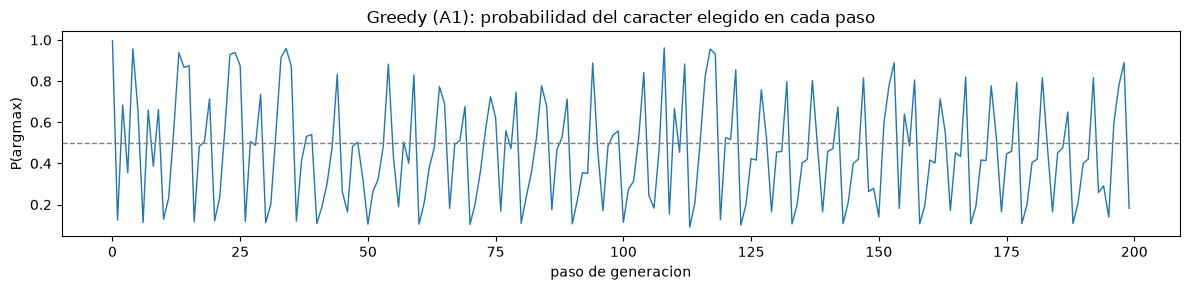

In [17]:
# (a) Evidencia del comportamiento greedy
g_text = samples['A'][0]
g_tr = traces['A'][0]
print('Las 5 muestras greedy son identicas:', len(set(samples['A'])) == 1)
print('Frecuencia de palabras en A1:', Counter(re.findall(r"[a-zA-Z']+", g_text)).most_common(6))
pmax = np.array([st['p_max'] for st in g_tr])
print(f'P(max) promedio en los pasos greedy: {pmax.mean():.3f} | pasos con P(max) < 0.5: {(pmax < 0.5).sum()} de {len(pmax)}')
print(f'P(max) promedio pasos 1-50: {pmax[:50].mean():.3f} | pasos 151-200: {pmax[-50:].mean():.3f}')

@torch.no_grad()
def next_probs(ctx, tau=1.0):
    ids = torch.tensor([encode(ctx)], device=device)[:, -block_size:]
    return softmax_temperature(model(ids)[0][0, -1], tau)

def top_str(pr, n=5):
    sp, si = torch.sort(pr, descending=True)
    return ', '.join(f'{itos[int(i)]!r}:{v:.2f}' for v, i in zip(sp[:n], si[:n]))

# Distribucion del siguiente caracter a lo largo de la palabra 'the shall'
print('\nDistribucion P(siguiente | contexto) en el inicio de A1:')
for j in [len('ROMEO:\nWhat '), len('ROMEO:\nWhat the'), len('ROMEO:\nWhat the '), len('ROMEO:\nWhat the s'),
          len('ROMEO:\nWhat the sh'), len('ROMEO:\nWhat the shall')]:
    full = PROMPT + g_text
    print(f'  {full[:j][-12:]!r:>16} -> {top_str(next_probs(full[:j]))}')

# Cada vez que greedy esta en 'the ', cual es la probabilidad de la 's' que elige?
full = PROMPT + g_text
p_s = [next_probs(full[:m.end()])[stoi['s']].item() for m in re.finditer('the ', full) if m.end() < len(full)]
print(f'\nP("s" | "...the ") en las {len(p_s)} apariciones: min {min(p_s):.3f}, max {max(p_s):.3f} '
      f'(primera {p_s[0]:.3f}, ultima {p_s[-1]:.3f})')
p_a = [next_probs(full[:m.end()])[stoi['a']].item() for m in re.finditer(' st', full)]
print(f'P("a" | "...st") en las {len(p_a)} apariciones: primera {p_a[0]:.3f}, ultima {p_a[-1]:.3f}')

plt.figure(figsize=(12, 3))
plt.plot(pmax, lw=1)
plt.axhline(0.5, ls='--', c='gray', lw=1)
plt.ylabel('P(argmax)'); plt.xlabel('paso de generacion')
plt.title('Greedy (A1): probabilidad del caracter elegido en cada paso')
plt.tight_layout(); plt.show()

tau=0.7: P(. | 'ROMEO:
I will ') = 't':0.17, 'n':0.16, 's':0.12, 'm':0.08, 'b':0.08, 'a':0.06, 'h':0.05, 'w':0.03
tau=1.0: P(. | 'ROMEO:
I will ') = 't':0.12, 'n':0.11, 's':0.09, 'm':0.07, 'b':0.07, 'a':0.06, 'h':0.05, 'w':0.04


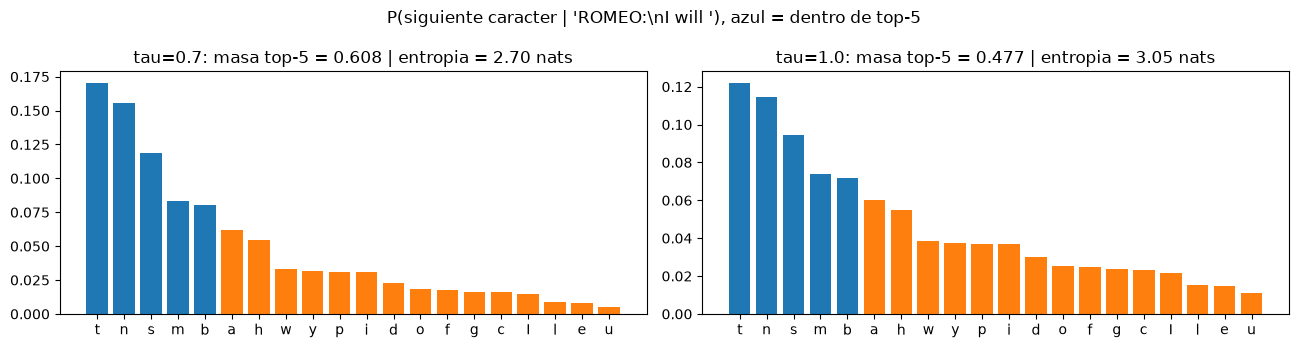

tau=0.7: masa promedio fuera del top-5 = 0.106 | pasos donde > 5% de la masa queda fuera: 38.8%
tau=1.0: masa promedio fuera del top-5 = 0.173 | pasos donde > 5% de la masa queda fuera: 62.5%


In [18]:
# (b) Efecto de tau y k sobre una distribucion real del modelo
@torch.no_grad()
def next_logits(ctx):
    ids = torch.tensor([encode(ctx)], device=device)[:, -block_size:]
    return model(ids)[0][0, -1]

for tau in [0.7, 1.0]:
    print(f"tau={tau}: P(. | 'ROMEO:\nI will ') = {top_str(next_probs('ROMEO:' + chr(10) + 'I will ', tau), 8)}")

ctx_b = 'ROMEO:\nI will '
zb = next_logits(ctx_b)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
for ax, tau in zip(axes, [0.7, 1.0]):
    pr = softmax_temperature(zb, tau)
    sp, si = torch.sort(pr, descending=True)
    ax.bar(range(20), sp[:20].cpu(), color=['C0' if i < 5 else 'C1' for i in range(20)])
    ax.set_xticks(range(20)); ax.set_xticklabels([repr(itos[int(i)])[1:-1] for i in si[:20]])
    ax.set_title(f'tau={tau}: masa top-5 = {sp[:5].sum():.3f} | entropia = {-(pr*torch.log(pr+1e-12)).sum():.2f} nats')
fig.suptitle(f'P(siguiente caracter | {ctx_b!r}), azul = dentro de top-5'); plt.tight_layout(); plt.show()

# Promedio sobre las muestras: masa que queda FUERA del top-5 (lo que B elimina y C conserva)
out5 = {0.7: [], 1.0: []}
for s in samples['C'][:2]:
    full = PROMPT + s
    for t in range(len(PROMPT), len(full), 5):
        z = next_logits(full[:t])
        for tau in out5:
            out5[tau].append(1 - torch.sort(softmax_temperature(z, tau), descending=True).values[:5].sum().item())
for tau, v in out5.items():
    print(f'tau={tau}: masa promedio fuera del top-5 = {np.mean(v):.3f} | pasos donde > 5% de la masa queda fuera: {np.mean(np.array(v) > .05):.1%}')

posicion                              n  nucleo medio  % nucleo=1
tras ":"                             12          1.08       91.7%
tras puntuacion                      28          1.57       42.9%
otro                                  1          6.00        0.0%
dentro de palabra                   769          7.78        4.9%
inicio de linea                      38         19.26        0.0%
inicio de palabra (tras espacio)    152         20.36        0.0%


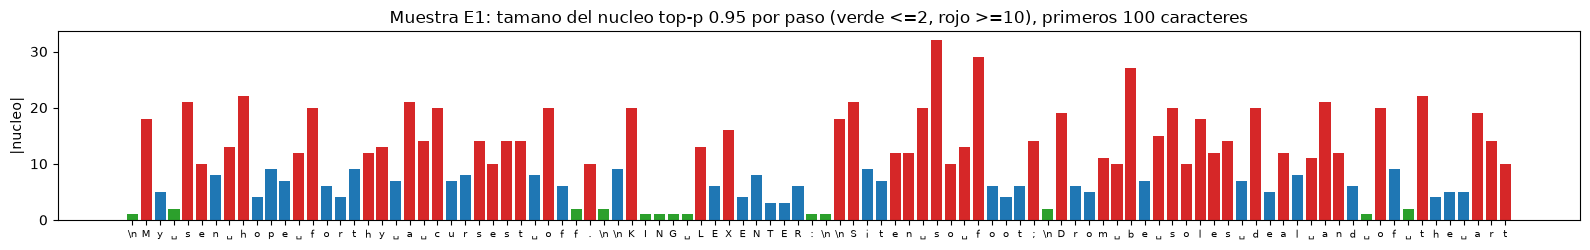

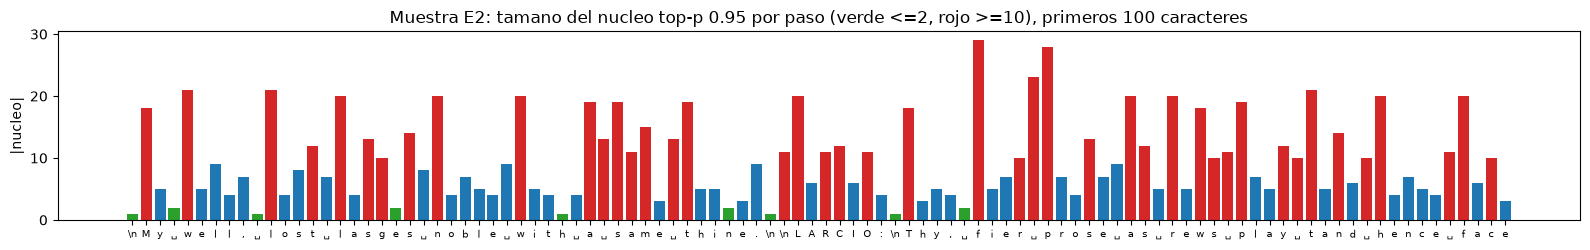

In [19]:
# (c) Configuracion E: tamano del nucleo top-p (p=0.95, tau=1) en cada paso
def char_class(prev, ch):
    if prev == '\n': return 'inicio de linea'
    if prev == ' ':  return 'inicio de palabra (tras espacio)'
    if prev in ':': return 'tras ":"'
    if prev in ',.;!?': return 'tras puntuacion'
    if prev.isalpha(): return 'dentro de palabra'
    return 'otro'

stats = defaultdict(list)
for tr in traces['E']:
    for st in tr:
        stats[char_class(st['prev'], st['char'])].append(st['nucleus95'])
print(f'{"posicion":<34} {"n":>4} {"nucleo medio":>13} {"% nucleo=1":>11}')
for k_, v in sorted(stats.items(), key=lambda kv: np.mean(kv[1])):
    v = np.array(v); print(f'{k_:<34} {len(v):>4} {v.mean():>13.2f} {np.mean(v == 1):>11.1%}')

# Visualizacion de la muestra E1/E2: cada caracter sobre el tamano del nucleo
for sid in [0, 1]:
    tr = traces['E'][sid]
    sizes = [st['nucleus95'] for st in tr[:100]]
    fig, ax = plt.subplots(figsize=(16, 2.6))
    ax.bar(range(len(sizes)), sizes, color=['C2' if s_ <= 2 else ('C3' if s_ >= 10 else 'C0') for s_ in sizes])
    ax.set_xticks(range(len(sizes)))
    ax.set_xticklabels([repr(st['char'])[1:-1].replace(' ', '␣') for st in tr[:100]], fontsize=7)
    ax.set_ylabel('|nucleo|'); ax.set_title(f'Muestra E{sid+1}: tamano del nucleo top-p 0.95 por paso (verde <=2, rojo >=10), primeros 100 caracteres')
    plt.tight_layout(); plt.show()

In [20]:
# Momentos concretos de seguridad / inseguridad en las muestras E (con su contexto)
def show_moments(trs, cond, n=6, title=''):
    print(title)
    shown = 0
    for sid, tr in enumerate(trs):
        gen = ''.join(st['char'] for st in tr)
        for t, st in enumerate(tr):
            if cond(st) and shown < n and t > 3:
                left = (PROMPT + gen)[max(0, len(PROMPT) + t - 25):len(PROMPT) + t]
                print(f'  E{sid+1} paso {t:3d}: ...{left!r} -> {st["char"]!r} | P(max)={st["p_max"]:.3f} '
                      f'| |nucleo|={st["nucleus95"]}')
                shown += 1
                break
    print()

show_moments(traces['E'], lambda st: st['nucleus95'] == 1 and st['prev'].isalpha(), title='SEGURO (nucleo de 1 caracter, dentro de palabra):')
show_moments(traces['E'], lambda st: st['nucleus95'] == 1 and not st['prev'].isalpha(), title='SEGURO (nucleo de 1 caracter, fuera de palabra):')
show_moments(traces['E'], lambda st: st['nucleus95'] >= 15, title='INSEGURO (nucleo >= 15 caracteres):')

SEGURO (nucleo de 1 caracter, dentro de palabra):
  E1 paso  37: ...' forthy a cursest off.\n\nK' -> 'I' | P(max)=0.983 | |nucleo|=1
  E2 paso  31: ...'ll, lost lasges noble wit' -> 'h' | P(max)=0.957 | |nucleo|=1
  E3 paso  30: ...'eporaded forth leave, lov' -> 'e' | P(max)=0.982 | |nucleo|=1
  E4 paso  78: ...'nt they betwer almes!\nHei' -> 'r' | P(max)=0.950 | |nucleo|=1
  E5 paso  47: ...' think. Comforce won,\nAre' -> ' ' | P(max)=0.976 | |nucleo|=1

SEGURO (nucleo de 1 caracter, fuera de palabra):
  E1 paso  50: ...'sest off.\n\nKING LEXENTER:' -> '\n' | P(max)=0.998 | |nucleo|=1
  E2 paso   9: ...'ROMEO:\nMy well,' -> ' ' | P(max)=0.973 | |nucleo|=1
  E3 paso  44: ...' leave, love of thy chis.' -> '\n' | P(max)=0.967 | |nucleo|=1
  E5 paso 112: ...'\ndoth purcuse self bloth,' -> ' ' | P(max)=0.961 | |nucleo|=1

INSEGURO (nucleo >= 15 caracteres):
  E1 paso   4: ...'ROMEO:\nMy ' -> 's' | P(max)=0.223 | |nucleo|=21
  E2 paso   4: ...'ROMEO:\nMy ' -> 'w' | P(max)=0.223 | |nucleo|=2